# 03 Exploratory Analysis

Objective: compare members and casual riders across volume, duration, seasonality, weekday/hour patterns, bike type, and station context. Figures are displayed inline and saved to `reports/figures/`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "scripts").exists():
    ROOT_DIR = ROOT_DIR.parent

sys.path.append(str(ROOT_DIR / "scripts"))

pd.options.display.float_format = "{:,.2f}".format

from bikeshare_analysis import (
    FIGURES_DIR,
    build_executive_summary,
    build_monthly_conversion_window,
    build_top_station_segments,
    configure_plot_style,
    create_report_assets,
    plot_bike_type_mix,
    plot_grouped_bars,
    plot_heatmap,
    plot_hourly_lines,
    plot_monthly_volume,
    plot_top_stations,
    read_processed,
)


## Generate Report Tables and Figures

The first cell rebuilds the report-ready tables and image files. Later cells re-render each chart inline for review.

In [2]:
assets = create_report_assets(close_figures=True)
executive_summary = build_executive_summary()
monthly_summary = build_monthly_conversion_window()
top_station_segments = build_top_station_segments()
weekday = read_processed("rides_by_weekday.csv")
hour = read_processed("rides_by_hour.csv")
bike_type = read_processed("rides_by_bike_type.csv")
heatmap = read_processed("rides_by_weekday_hour.csv")

configure_plot_style()
display(executive_summary)

,member_casual,rides,ride_share_pct,avg_ride_minutes,most_common_day_of_week,most_common_start_hour,weekend_ride_share_pct,commute_window_share_pct,round_trip_share_pct
0,casual,2008741,35.90,19.13,Saturday,17,37.24,25.33,5.99
1,member,3587101,64.10,12.01,Thursday,17,23.27,38.64,1.95


## Monthly Volume and Casual Share

This chart shows both absolute demand and the seasonal window where casual riders make up a larger share of trips.

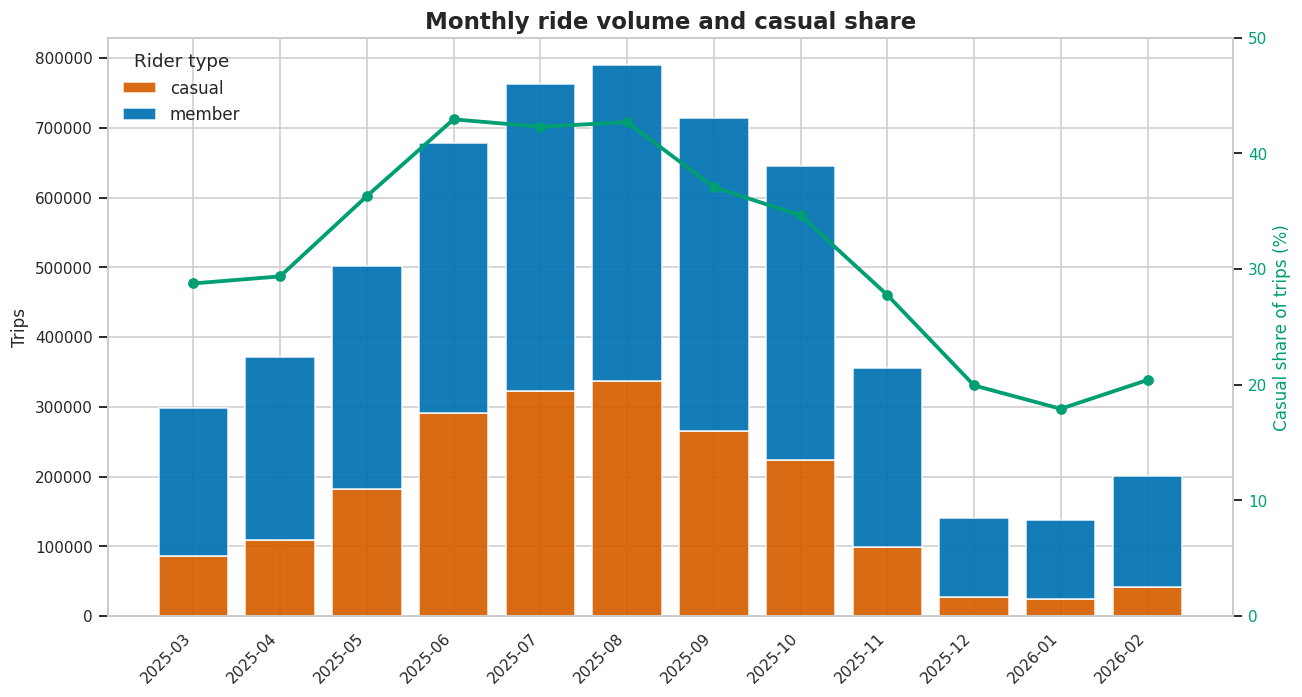

In [3]:
fig = plot_monthly_volume(monthly_summary, FIGURES_DIR / "monthly_ride_volume.png")
plt.show()

## Weekday Ride Volume

The comparison highlights weekday versus weekend behavior across rider types.

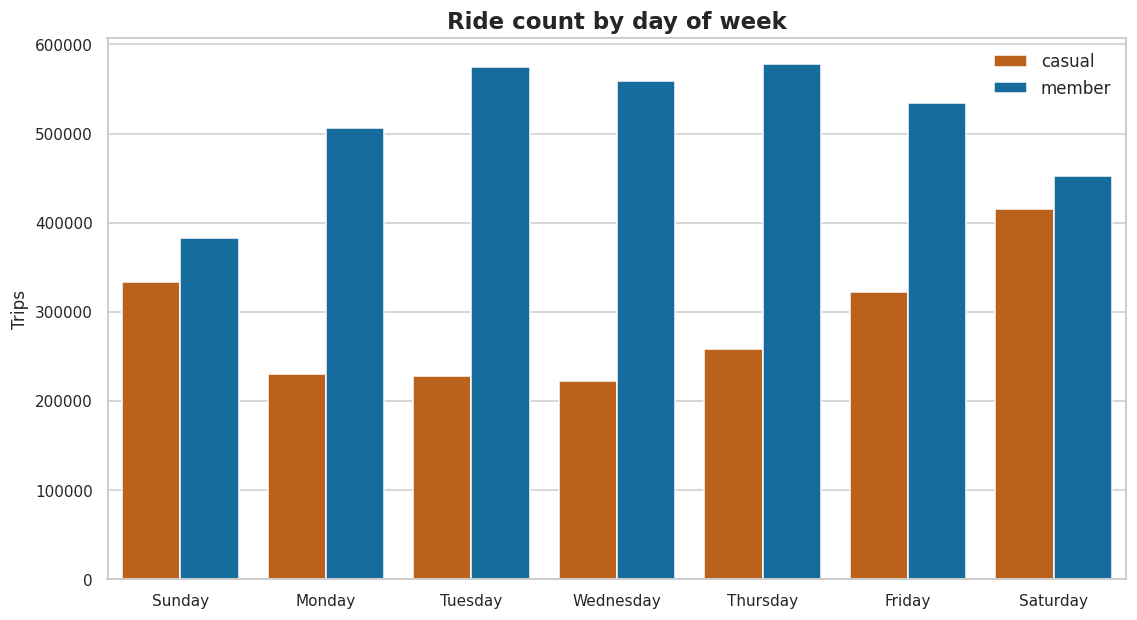

In [4]:
fig = plot_grouped_bars(
    weekday,
    "day_of_week",
    "rides",
    "Ride count by day of week",
    "Trips",
    FIGURES_DIR / "rides_by_weekday.png",
)
plt.show()

## Average Ride Length by Weekday

Duration is used as a behavioral signal, not as a proxy for customer value.

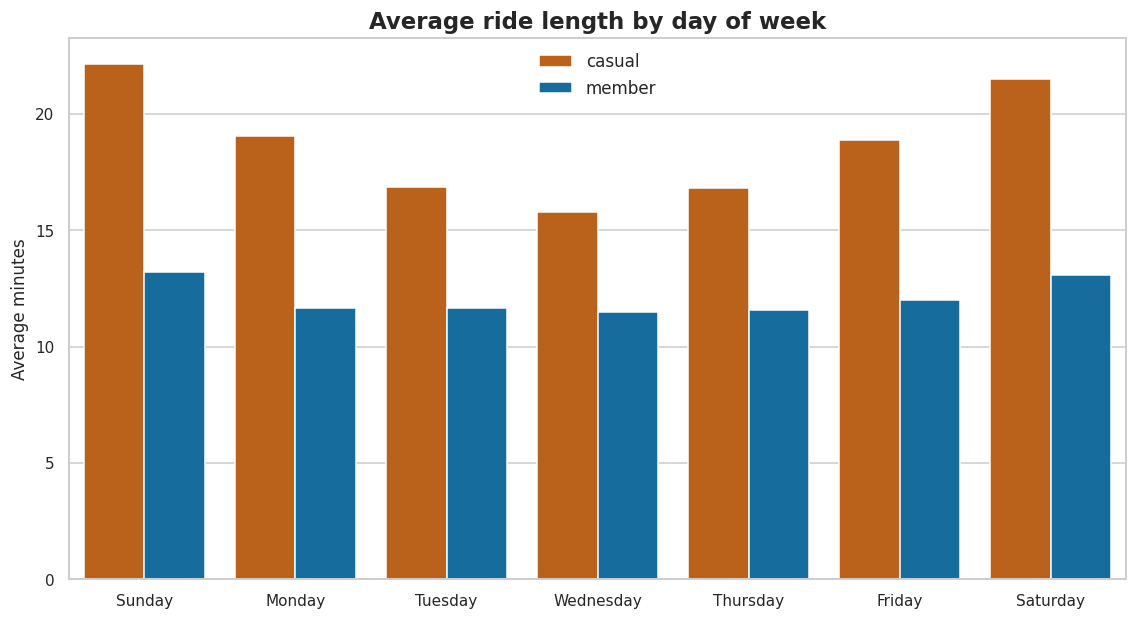

In [5]:
fig = plot_grouped_bars(
    weekday,
    "day_of_week",
    "avg_ride_minutes",
    "Average ride length by day of week",
    "Average minutes",
    FIGURES_DIR / "avg_ride_length_by_weekday.png",
)
plt.show()

## Hourly Usage Pattern

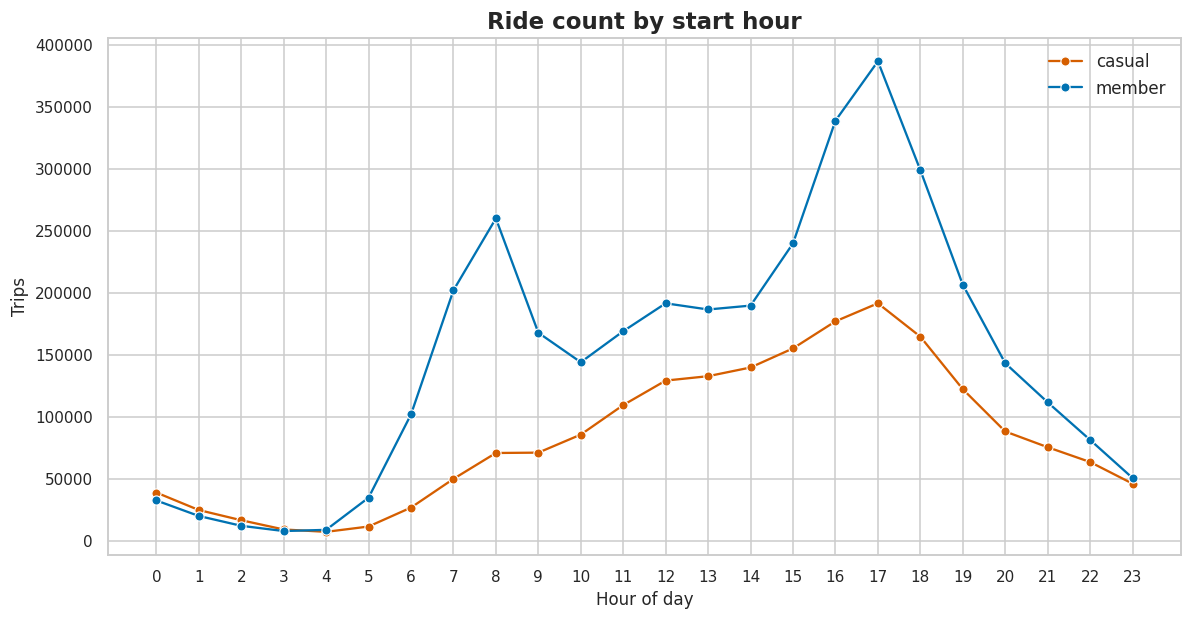

In [6]:
fig = plot_hourly_lines(hour, FIGURES_DIR / "rides_by_hour.png")
plt.show()

## Weekly Heatmap

The heatmap makes the commuting and leisure timing differences easier to inspect.

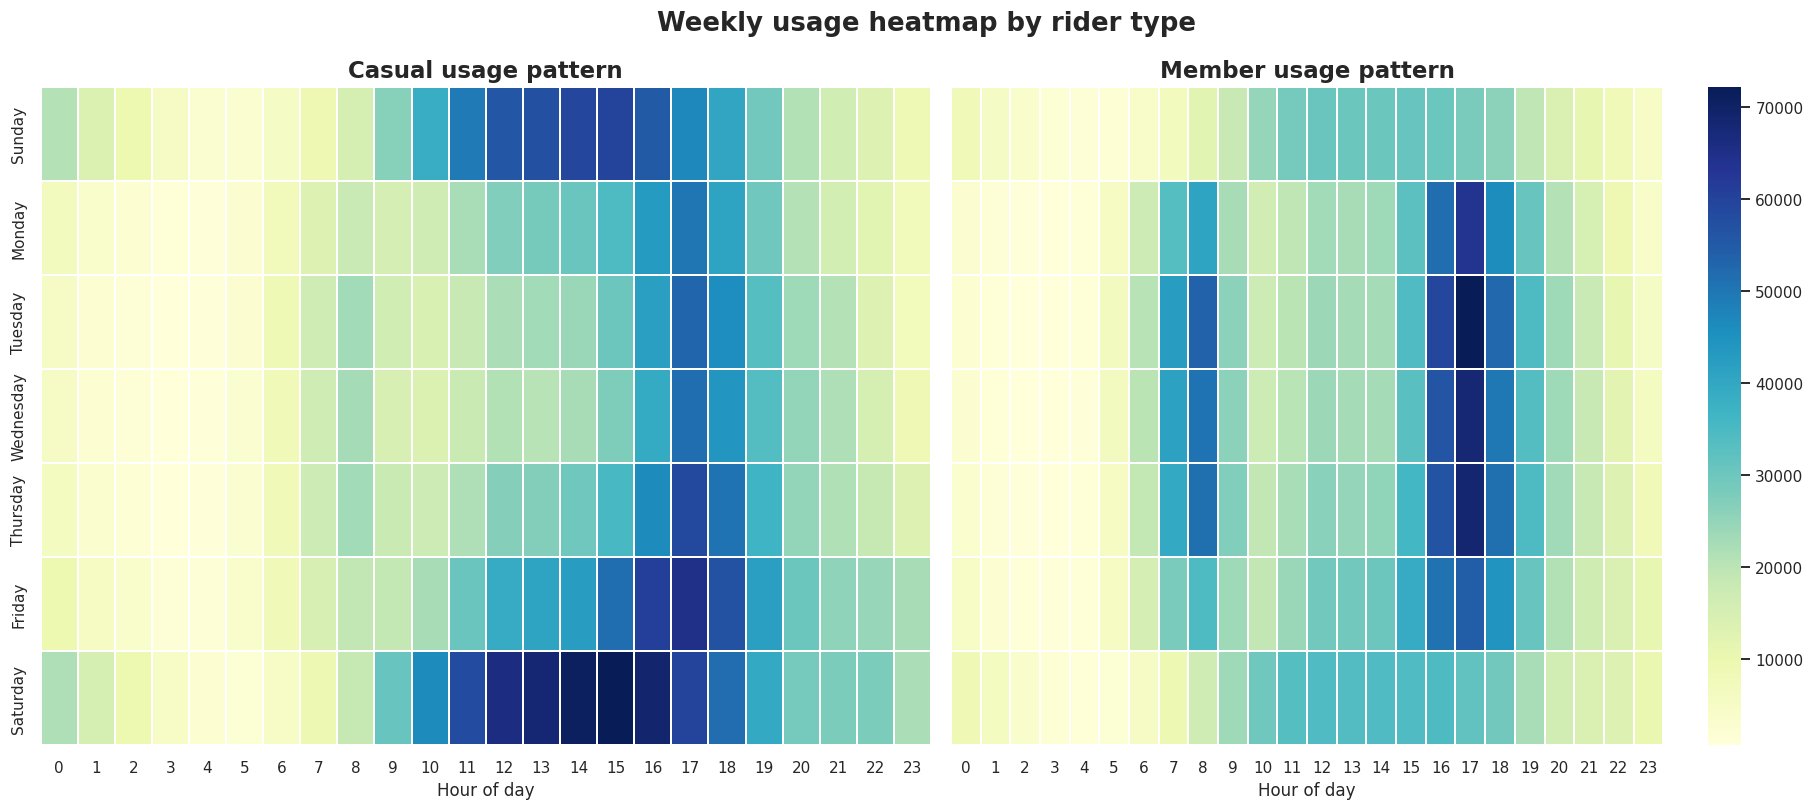

In [7]:
fig = plot_heatmap(heatmap, FIGURES_DIR / "usage_heatmap.png")
plt.show()

## Bike Type Mix

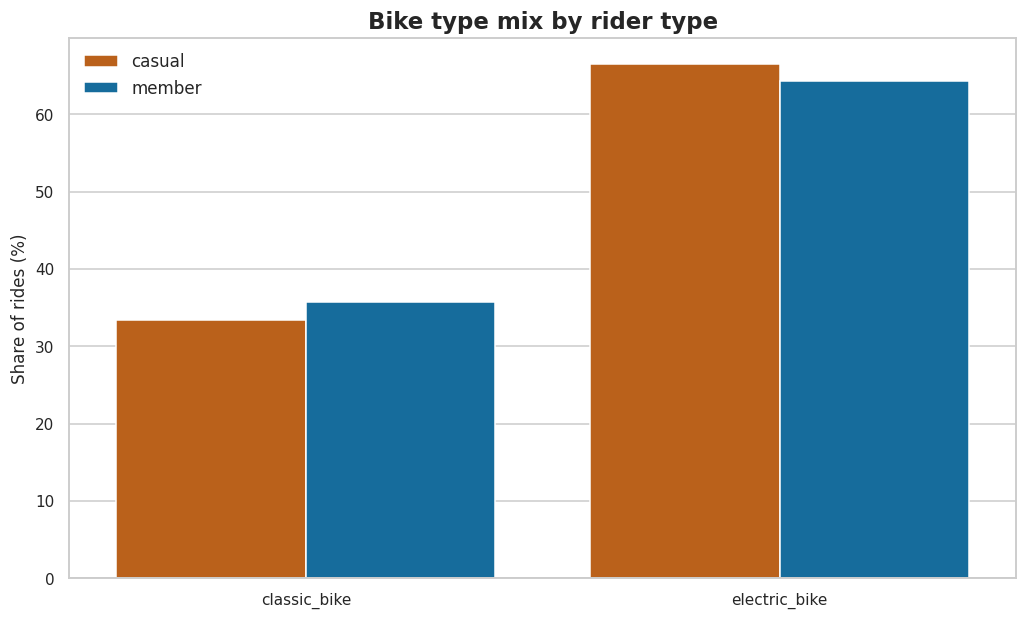

In [8]:
fig = plot_bike_type_mix(bike_type, FIGURES_DIR / "bike_type_mix.png")
plt.show()

## Top Start Stations

Station analysis uses only trips with nonblank start station names.

,member_casual,rank,start_station_name,rides
0,casual,1,DuSable Lake Shore Dr & Monroe St,31411
1,casual,2,Navy Pier,28050
2,casual,3,Streeter Dr & Grand Ave,23248
3,casual,4,Michigan Ave & Oak St,22450
4,casual,5,DuSable Lake Shore Dr & North Blvd,19515
5,casual,6,Millennium Park,19081
6,casual,7,Shedd Aquarium,16902
7,casual,8,Theater on the Lake,15808
8,casual,9,Dusable Harbor,15591
9,casual,10,Michigan Ave & 8th St,11190


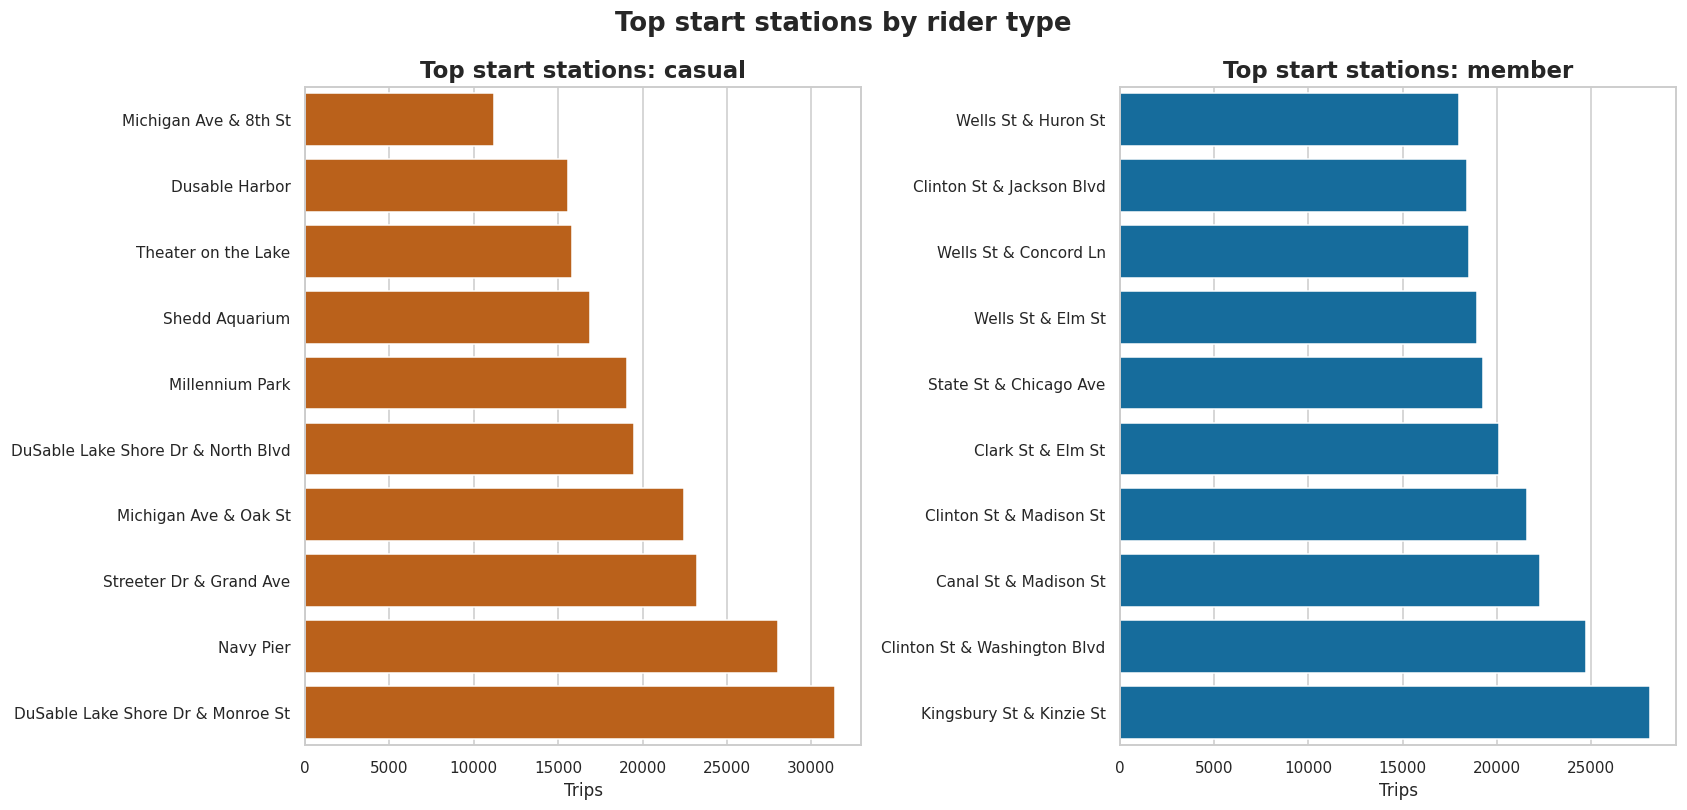

In [9]:
display(top_station_segments)
fig = plot_top_stations(top_station_segments, FIGURES_DIR / "top_stations_comparison.png")
plt.show()

## EDA Takeaways

- Members take more rides overall and show stronger weekday commute-window behavior.
- Casual riders take longer rides and show stronger weekend and warm-month patterns.
- Top casual start stations are concentrated around visitor- and leisure-oriented areas, which supports location-based marketing tests.
- The public dataset supports behavioral comparison, but not causal conversion modeling.